# Training models to find the best one for baseline 

In [26]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

### 1. Downloading dataset and finding class distribution 

In [27]:
df = pd.read_csv("/Users/annalappo/Desktop/GitHub_2/Data-Drift-Challenge/Anna_Lappo/creditcard.csv")

print(f"Dataset shape: {df.shape}")
print(f"Features: {df.shape[1] - 1}")


counts = df["Class"].value_counts()
total  = len(df)
print(f"\nClass distribution:")
print(f"Not fraud (0): {counts[0]:,}")
print(f"Fraud (1): {counts[1]:,}")
print(f"Imbalance ratio: {counts[0]//counts[1]}:1")

Dataset shape: (284807, 31)
Features: 30

Class distribution:
Not fraud (0): 284,315
Fraud (1): 492
Imbalance ratio: 577:1


### 2. Splitting dataset into train/test sets

In [28]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,        
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"\nTrain size: {len(X_train):,} samples")
print(f"Test size: {len(X_test):,}  samples")
print(f"Fraud in test set: {y_test.sum()} cases")
print(f"Scale_pos_weight: {scale_pos_weight:.1f}")


Train size: 227,845 samples
Test size: 56,962  samples
Fraud in test set: 98 cases
Scale_pos_weight: 577.3


### 3. Creating models for training

In [29]:
Logistic_Regression = LogisticRegression(
    max_iter=200,              
    random_state=42,
    #class_weight="balanced"
)
print('Finished training')

Finished training


In [30]:
xgboost = xgb.XGBClassifier(
    n_estimators=100,                 
    max_depth=4,                         
    learning_rate=0.1,                   
    scale_pos_weight=scale_pos_weight,  
    subsample=0.8,                      
    colsample_bytree=0.8,               
    random_state=42,
    eval_metric="logloss",
    verbosity=0,
)
print('Finished training')

Finished training


In [31]:
Random_Forest = RandomForestClassifier(
    n_estimators=100,          
    #max_depth=15,             
    class_weight="balanced",  
    random_state=42,
    n_jobs=-1,                
)
print('Finished training')

Finished training


### 4. Training and evaluating model wth test set

--------------------
RESULTS
MODEL: Logistic Regression
F1 : 0.7168
AUC-ROC: 0.9605
Precision: 0.8267
Recall: 0.6327

Classification report:
              precision    recall  f1-score   support

   Not fraud       1.00      1.00      1.00     56864
       Fraud       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

Confusion matrix:


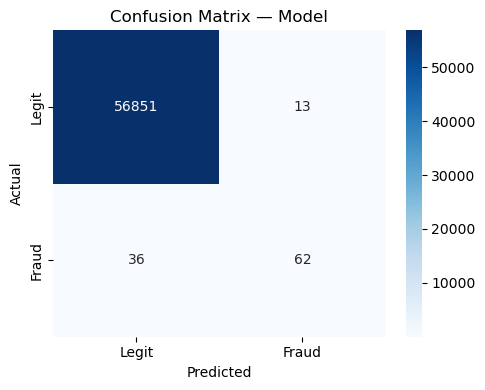

--------------------
RESULTS
MODEL: XGBoost
F1 : 0.5397
AUC-ROC: 0.9771
Precision: 0.3917
Recall: 0.8673

Classification report:
              precision    recall  f1-score   support

   Not fraud       1.00      1.00      1.00     56864
       Fraud       0.39      0.87      0.54        98

    accuracy                           1.00     56962
   macro avg       0.70      0.93      0.77     56962
weighted avg       1.00      1.00      1.00     56962

Confusion matrix:


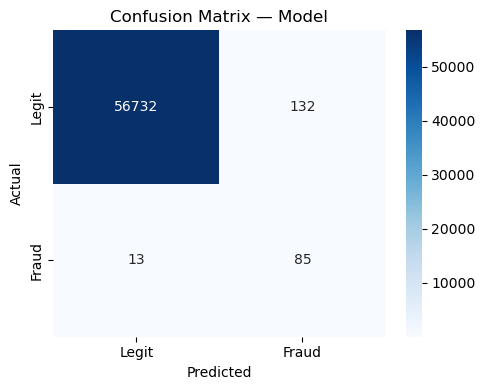

--------------------
RESULTS
MODEL: Random Forest
F1 : 0.8391
AUC-ROC: 0.9529
Precision: 0.9605
Recall: 0.7449

Classification report:
              precision    recall  f1-score   support

   Not fraud       1.00      1.00      1.00     56864
       Fraud       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion matrix:


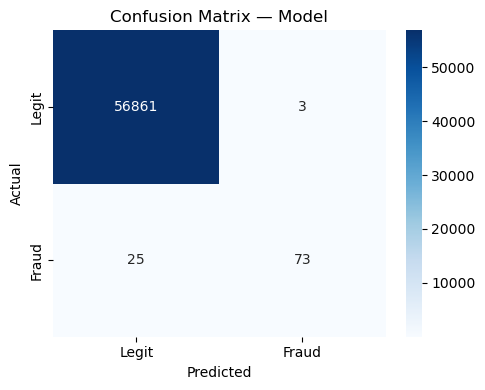

In [32]:
models = {
    "Logistic Regression": Logistic_Regression,
    "XGBoost": xgboost,
    "Random Forest": Random_Forest
}
for name, i in models.items():
    i.fit(X_train_sc, y_train)
    y_pred = i.predict(X_test_sc)
    y_prob = i.predict_proba(X_test_sc)[:, 1]
    threshold = 0.9
    y_pred_a = (y_prob >= threshold).astype(int)
    results = {
    "F1":        f1_score(y_test, y_pred),
    "AUC-ROC":   roc_auc_score(y_test, y_prob),
    "Precision": precision_score(y_test, y_pred),
    "Recall":    recall_score(y_test, y_pred),
}
    #f1 = f1_score(y_test, y_pred, pos_label=1, average="binary")
    #auc_roc = roc_auc_score(y_test, y_prob)
    #precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    #recall = recall_score(y_test, y_pred, pos_label=1)
    print("-" * 20)
    print("RESULTS")
    print(f"MODEL: {name}")
    print(f"F1 : {results['F1']:.4f}")
    print(f"AUC-ROC: {results['AUC-ROC']:.4f}")
    print(f"Precision: {results['Precision']:.4f}")
    print(f"Recall: {results['Recall']:.4f}")

    results_df = pd.DataFrame([results])
    results_df.to_csv(f"results_{name}.csv", index=False)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=["Not fraud", "Fraud"]))

    print("Confusion matrix:")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Legit", "Fraud"],
                yticklabels=["Legit", "Fraud"])
    plt.title(f"Confusion Matrix — Model")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

#### Based on results from evaluation, we can conclude that model Random Forest Classifier is th ebest one for our classification case. 

In [34]:
joblib.dump(Random_Forest,"Random_Forest.pkl")
columns = [c for c in df.columns if c not in ["Class", "day"]]
joblib.dump(columns, "colomns.pkl")
print("\nModel saved")


Model saved
